# Geospatial Modeling of Preterm Birth Risk Across  Some U.S. Counties: A Health Security Perspective

## Module 3 Project: Initial Analysis

**Course:** GEOG 5199/6099 - Exploratory Data Analytics with GIS

**Student_ID:** M16613522

**Semester:** Spring 2026

---


## 1. Introduction

This notebook presents a preliminary analysis of county-level preterm birth rates across the United States. Preterm birth, defined as delivery before 37 completed weeks of gestation, remains one of the most pressing maternal and child health challenges in the U.S., with the national rate holding steady at 10.4% for four consecutive years (March of Dimes, 2025). The societal economic burden associated with preterm birth has been estimated at \$25.2 billion annually.

This initial analysis covers data preparation, cleaning, pre-processing, and descriptive statistical analysis of the project dataset, which integrates birth outcome data from CDC WONDER (2023) with socioeconomic and healthcare access indicators from the American Community Survey (ACS) 1-Year Estimates (2023), supplemented by county centroid coordinates from the Census Bureau Gazetteer Files.

### Research Questions

1. What are the key socioeconomic and healthcare access predictors of county-level preterm birth rates in the United States, and do these relationships exhibit spatial non-stationarity across U.S. counties? If so, how do these relationships vary geographically?

2. How accurately can machine learning models predict county-level preterm birth rates using these indicators, and which predictors contribute most to model performance?

3. Which U.S. counties are at the highest predicted risk for elevated preterm birth rates, and what localized factors drive that risk?

## 2. Library Imports and Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import geopandas as gpd
import mapclassify
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 3. Data Loading and Inspection

In [7]:
# Load the analysis dataset
df = pd.read_csv('preterm_birth_analysis_dataset_final.csv', dtype={'FIPS': str})

# Zero-pad FIPS codes to 5 digits for shapefile merge
df['FIPS'] = df['FIPS'].str.zfill(5)

# Display basic information
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumn Names:\n{df.columns.tolist()}')
print(f'\nFIPS code sample (zero-padded): {df["FIPS"].head().tolist()}')

Dataset Shape: 570 rows x 16 columns

Column Names:
['FIPS', 'County', 'Total_Births', 'Preterm_Births', 'Preterm_Rate', 'Pct_Poverty', 'Pct_Uninsured', 'Pct_Bachelors', 'Median_HH_Income', 'Unemployment_Rate', 'Total_Population', 'Median_Age', 'Pct_White', 'Pct_Black', 'Latitude', 'Longitude']

FIPS code sample (zero-padded): ['01003', '01015', '01055', '01069', '01073']


In [9]:
# ============================================================
# Load U.S. county boundary shapefile and merge with dataset
# ============================================================
# INSTRUCTIONS: Download the Census Bureau county boundary file:
#   URL: https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip
#   Save the ZIP file in the same folder as this notebook.
# ============================================================

import os

# Load county boundaries from Census Bureau shapefile
shapefile_path = 'cb_2023_us_county_500k.zip'

if os.path.exists(shapefile_path):
    counties_gdf = gpd.read_file(shapefile_path)
    # Create 5-digit FIPS from state + county FIPS codes
    counties_gdf['FIPS'] = counties_gdf['STATEFP'] + counties_gdf['COUNTYFP']
else:
    # Alternative: read directly from Census Bureau (requires internet)
    print('Local shapefile not found. Downloading from Census Bureau...')
    counties_gdf = gpd.read_file(
        'https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip'
    )
    counties_gdf['FIPS'] = counties_gdf['STATEFP'] + counties_gdf['COUNTYFP']

# Filter to continental U.S. (exclude AK=02, HI=15, and territories)
exclude_fips = ['02', '15', '60', '66', '69', '72', '78']
counties_gdf = counties_gdf[~counties_gdf['STATEFP'].isin(exclude_fips)].copy()

# Reproject to WGS 84 (EPSG:4326) for consistency
counties_gdf = counties_gdf.to_crs(epsg=4326)

# Merge preterm birth data with county boundaries
gdf = counties_gdf.merge(df, on='FIPS', how='inner')

print(f'County boundaries loaded: {len(counties_gdf)} continental U.S. counties')
print(f'Matched with preterm data: {len(gdf)} counties (of {len(df)} in dataset)')
print(f'Unmatched counties: {len(df) - len(gdf)}')

if len(df) - len(gdf) > 0:
    unmatched_fips = set(df['FIPS']) - set(gdf['FIPS'])
    print(f'Unmatched FIPS (first 10): {sorted(list(unmatched_fips))[:10]}')

County boundaries loaded: 3109 continental U.S. counties
Matched with preterm data: 566 counties (of 570 in dataset)
Unmatched counties: 4
Unmatched FIPS (first 10): ['02020', '15001', '15003', '15009']


In [11]:
# Inspect the first 5 rows
df.head()

,FIPS,County,Total_Births,Preterm_Births,Preterm_Rate,Pct_Poverty,Pct_Uninsured,Pct_Bachelors,Median_HH_Income,Unemployment_Rate,Total_Population,Median_Age,Pct_White,Pct_Black,Latitude,Longitude
0,01003,"Baldwin County, AL",2486,248,9.98,9.70,6.80,32.00,72915,2.00,253507,44.30,82.10,8.30,30.66,-87.75
1,01015,"Calhoun County, AL",1258,153,12.16,21.30,8.90,23.70,50780,5.40,116429,40.50,71.70,21.80,33.77,-85.83
2,01055,"Etowah County, AL",1163,115,9.89,20.90,10.90,18.00,52192,6.60,103241,41.20,76.70,15.10,34.05,-86.03
3,01069,"Houston County, AL",1278,166,12.99,16.70,10.00,22.90,59335,4.00,108462,39.90,64.30,27.40,31.16,-85.30
4,01073,"Jefferson County, AL",7866,1013,12.88,15.90,9.40,36.70,64623,3.50,662895,38.00,47.90,42.30,33.55,-86.90


In [15]:
# Data types
print('Data Types:')
print(df.dtypes)

Data Types:
FIPS                  object
County                object
Total_Births           int64
Preterm_Births         int64
Preterm_Rate         float64
Pct_Poverty          float64
Pct_Uninsured        float64
Pct_Bachelors        float64
Median_HH_Income       int64
Unemployment_Rate    float64
Total_Population       int64
Median_Age           float64
Pct_White            float64
Pct_Black            float64
Latitude             float64
Longitude            float64
dtype: object


In [17]:
# Check the dataset dimensions
print(f'Number of counties: {df.shape[0]}')
print(f'Number of variables: {df.shape[1]}')

Number of counties: 570
Number of variables: 16


## 4. Data Cleaning and Pre-processing

### 4.1 Checking for Missing Values

In [21]:
# Check for missing values
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values per Column:
FIPS                 0
County               0
Total_Births         0
Preterm_Births       0
Preterm_Rate         0
Pct_Poverty          0
Pct_Uninsured        0
Pct_Bachelors        0
Median_HH_Income     0
Unemployment_Rate    0
Total_Population     0
Median_Age           0
Pct_White            0
Pct_Black            0
Latitude             0
Longitude            0
dtype: int64

Total missing values: 0


### 4.2 Checking for Duplicates

In [24]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

# Check for duplicate FIPS codes (should be unique)
print(f'Duplicate FIPS codes: {df["FIPS"].duplicated().sum()}')

Duplicate rows: 0
Duplicate FIPS codes: 0


### 4.3 Data Type Validation

In [27]:
# Ensure numeric columns are properly typed
numeric_cols = ['Total_Births', 'Preterm_Births', 'Preterm_Rate', 'Pct_Poverty', 
                'Pct_Uninsured', 'Pct_Bachelors', 'Median_HH_Income', 
                'Unemployment_Rate', 'Total_Population', 'Median_Age', 
                'Pct_White', 'Pct_Black', 'Latitude', 'Longitude']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verify no new missing values were introduced
print('Missing values after type conversion:')
print(df[numeric_cols].isnull().sum())
print('\nAll numeric columns validated successfully.')

Missing values after type conversion:
Total_Births         0
Preterm_Births       0
Preterm_Rate         0
Pct_Poverty          0
Pct_Uninsured        0
Pct_Bachelors        0
Median_HH_Income     0
Unemployment_Rate    0
Total_Population     0
Median_Age           0
Pct_White            0
Pct_Black            0
Latitude             0
Longitude            0
dtype: int64

All numeric columns validated successfully.


### 4.4 Checking for Outliers

In [30]:
# Check for potential outliers using IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print(f'{"Variable":<25} {"Outliers":<10} {"Lower Bound":<15} {"Upper Bound":<15}')
print('-' * 65)
for col in ['Preterm_Rate', 'Pct_Poverty', 'Pct_Uninsured', 'Pct_Bachelors',
            'Median_HH_Income', 'Unemployment_Rate', 'Total_Population', 
            'Median_Age', 'Pct_White', 'Pct_Black']:
    n_out, lower, upper = detect_outliers_iqr(df[col])
    print(f'{col:<25} {n_out:<10} {lower:<15.2f} {upper:<15.2f}')

Variable                  Outliers   Lower Bound     Upper Bound    
-----------------------------------------------------------------
Preterm_Rate              12         6.02            14.66          
Pct_Poverty               6          0.00            24.00          
Pct_Uninsured             14         -2.35           16.45          
Pct_Bachelors             6          5.56            63.86          
Median_HH_Income          16         25942.38        130327.38      
Unemployment_Rate         14         0.65            7.45           
Total_Population          47         -350607.88      1010291.12     
Median_Age                24         29.80           48.20          
Pct_White                 4          18.29           116.79         
Pct_Black                 30         -17.04          36.66          


### 4.5 Skewness Assessment and Log Transformations

Variables with absolute skewness greater than 1 are candidates for logarithmic transformation to approximate normality, which improves the performance of regression-based models (OLS, GWR). Tree-based methods (Random Forest, Gradient Boosting) do not require this transformation.

In [33]:
# Assess skewness for all predictor variables
print("SKEWNESS ASSESSMENT")
print("=" * 65)
print(f"{'Variable':<25} {'Skewness':<12} {'Action'}")
print("-" * 65)

transform_candidates = ['Preterm_Rate', 'Pct_Poverty', 'Pct_Uninsured', 'Pct_Bachelors',
                         'Median_HH_Income', 'Unemployment_Rate', 'Total_Population', 
                         'Median_Age', 'Pct_White', 'Pct_Black']

for col in transform_candidates:
    skew = df[col].skew()
    action = "*** LOG TRANSFORM" if abs(skew) > 1 else "OK"
    print(f"  {col:<25} {skew:+.3f}       {action}")

print("\nVariables with |skewness| > 1 will be log-transformed.")

SKEWNESS ASSESSMENT
Variable                  Skewness     Action
-----------------------------------------------------------------
  Preterm_Rate              +0.946       OK
  Pct_Poverty               +0.612       OK
  Pct_Uninsured             +1.504       *** LOG TRANSFORM
  Pct_Bachelors             +0.595       OK
  Median_HH_Income          +1.103       *** LOG TRANSFORM
  Unemployment_Rate         +0.854       OK
  Total_Population          +6.755       *** LOG TRANSFORM
  Median_Age                +0.963       OK
  Pct_White                 -0.679       OK
  Pct_Black                 +1.871       *** LOG TRANSFORM

Variables with |skewness| > 1 will be log-transformed.


In [35]:
# Apply log transformations to skewed variables
# log1p = log(1 + x), handles zero values safely
# log10 used for Total_Population due to large magnitude

print("LOG TRANSFORMATIONS")
print("=" * 65)

# 1. Total Population (skewness > 6)
print(f"\n1. Total_Population:")
print(f"   Before: skewness = {df['Total_Population'].skew():.3f}")
df['Log_Population'] = np.log10(df['Total_Population'])
print(f"   After (log10): skewness = {df['Log_Population'].skew():.3f}")

# 2. Pct_Black (skewness > 1.8)
print(f"\n2. Pct_Black:")
print(f"   Before: skewness = {df['Pct_Black'].skew():.3f}")
df['Log_Pct_Black'] = np.log1p(df['Pct_Black'])
print(f"   After (log1p): skewness = {df['Log_Pct_Black'].skew():.3f}")

# 3. Pct_Uninsured (skewness > 1.5)
print(f"\n3. Pct_Uninsured:")
print(f"   Before: skewness = {df['Pct_Uninsured'].skew():.3f}")
df['Log_Pct_Uninsured'] = np.log1p(df['Pct_Uninsured'])
print(f"   After (log1p): skewness = {df['Log_Pct_Uninsured'].skew():.3f}")

# 4. Median_HH_Income (skewness > 1.1)
print(f"\n4. Median_HH_Income:")
print(f"   Before: skewness = {df['Median_HH_Income'].skew():.3f}")
df['Log_Median_HH_Income'] = np.log10(df['Median_HH_Income'])
print(f"   After (log10): skewness = {df['Log_Median_HH_Income'].skew():.3f}")

print(f"\nNew columns added: Log_Population, Log_Pct_Black, Log_Pct_Uninsured, Log_Median_HH_Income")
print(f"Updated dataset shape: {df.shape}")

LOG TRANSFORMATIONS

1. Total_Population:
   Before: skewness = 6.755
   After (log10): skewness = 0.955

2. Pct_Black:
   Before: skewness = 1.871
   After (log1p): skewness = 0.023

3. Pct_Uninsured:
   Before: skewness = 1.504
   After (log1p): skewness = 0.114

4. Median_HH_Income:
   Before: skewness = 1.103
   After (log10): skewness = 0.438

New columns added: Log_Population, Log_Pct_Black, Log_Pct_Uninsured, Log_Median_HH_Income
Updated dataset shape: (570, 20)


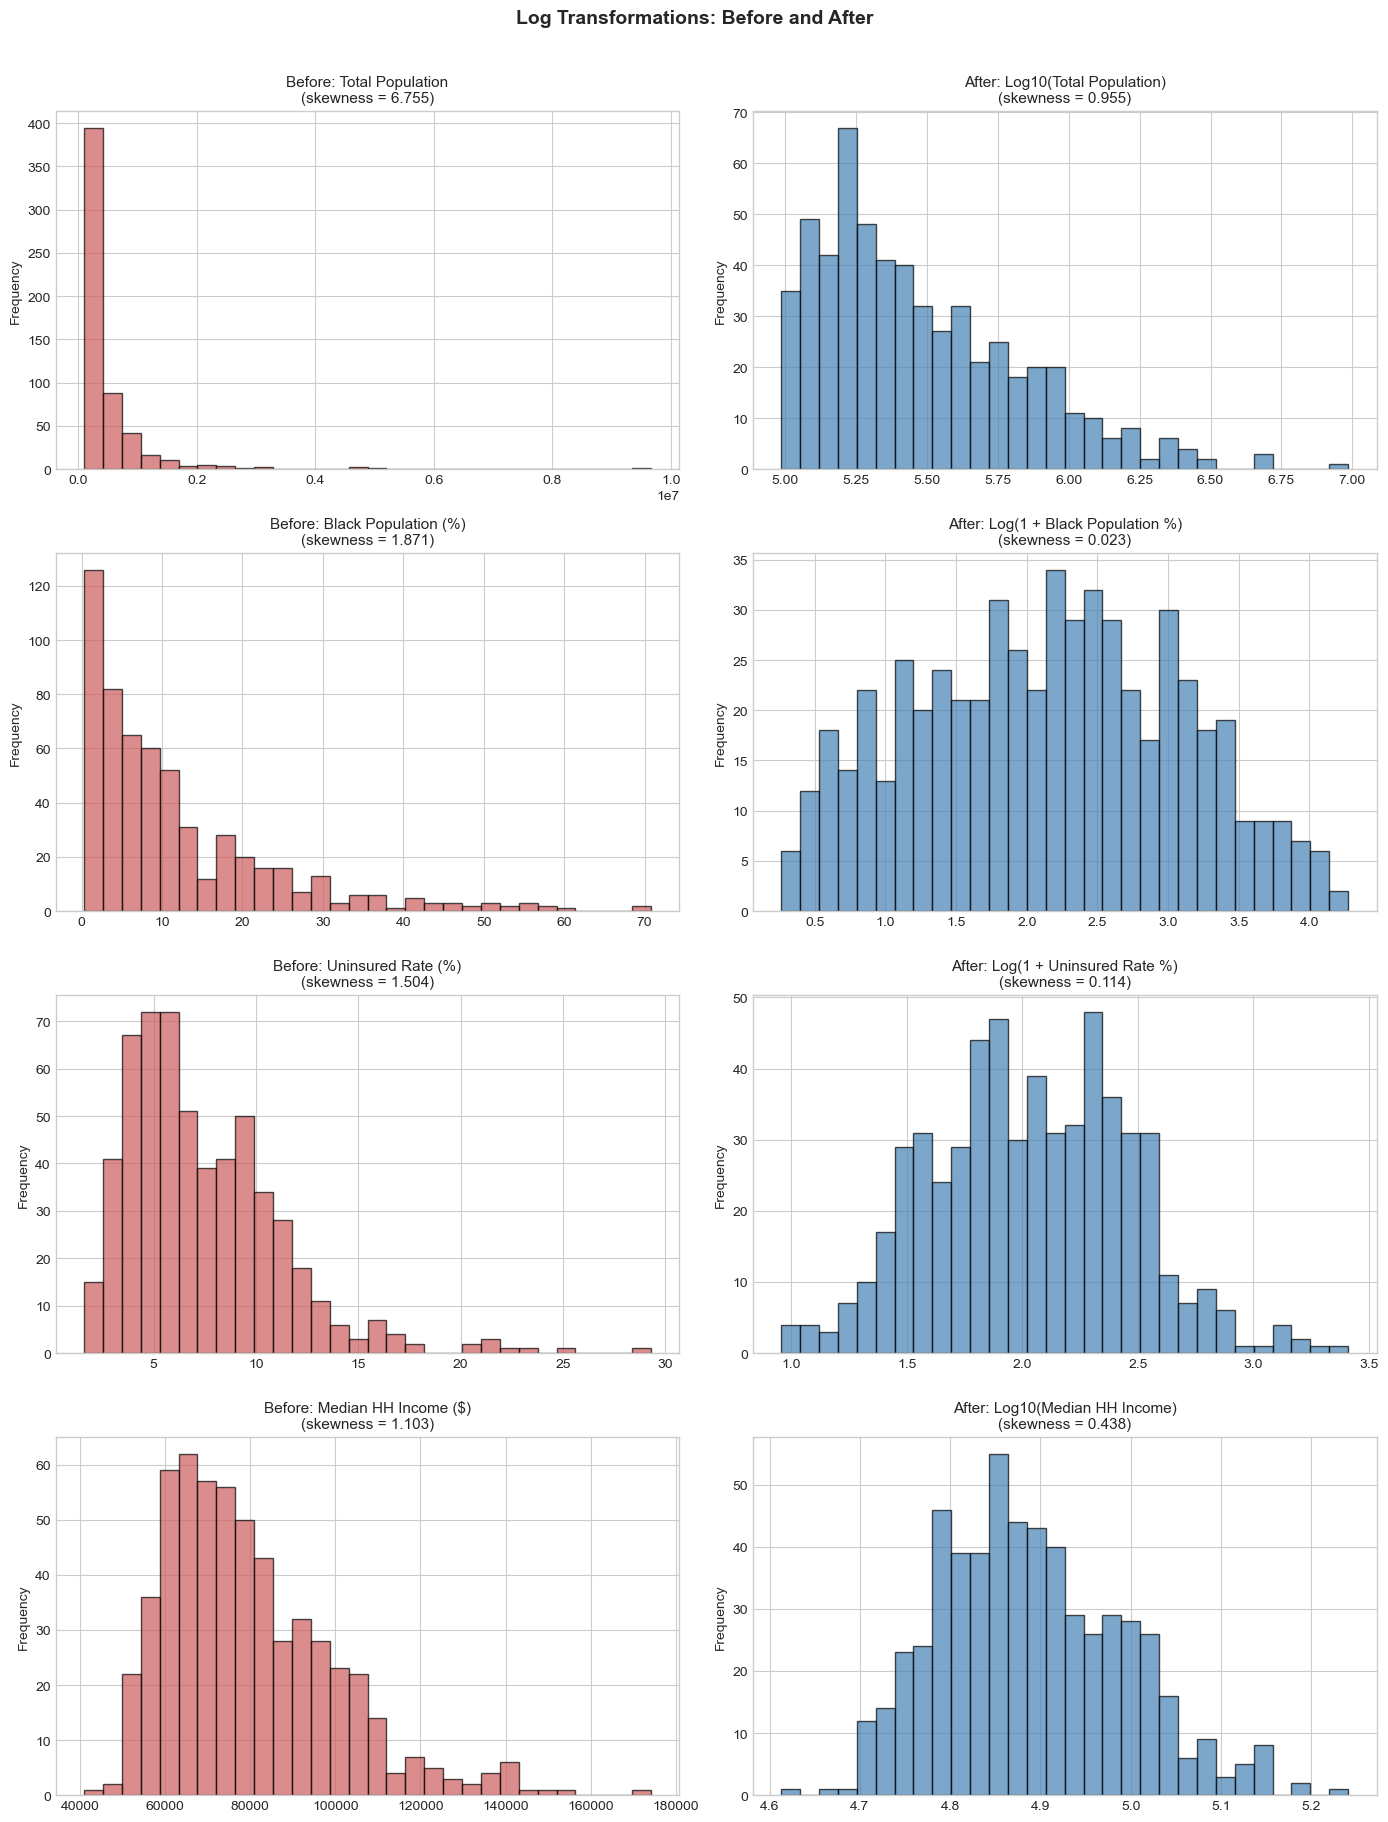

All four variables show substantially reduced skewness after transformation.


In [37]:
# Visualize before and after transformation
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

transform_pairs = [
    ('Total_Population', 'Log_Population', 'Total Population', 'Log10(Total Population)'),
    ('Pct_Black', 'Log_Pct_Black', 'Black Population (%)', 'Log(1 + Black Population %)'),
    ('Pct_Uninsured', 'Log_Pct_Uninsured', 'Uninsured Rate (%)', 'Log(1 + Uninsured Rate %)'),
    ('Median_HH_Income', 'Log_Median_HH_Income', 'Median HH Income ($)', 'Log10(Median HH Income)')
]

for idx, (orig, transformed, orig_label, trans_label) in enumerate(transform_pairs):
    # Before
    axes[idx, 0].hist(df[orig], bins=30, edgecolor='black', alpha=0.7, color='indianred')
    axes[idx, 0].set_title(f'Before: {orig_label}\n(skewness = {df[orig].skew():.3f})', fontsize=11)
    axes[idx, 0].set_ylabel('Frequency')
    
    # After
    axes[idx, 1].hist(df[transformed], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx, 1].set_title(f'After: {trans_label}\n(skewness = {df[transformed].skew():.3f})', fontsize=11)
    axes[idx, 1].set_ylabel('Frequency')

plt.suptitle('Log Transformations: Before and After', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_log_transformations.png', dpi=150, bbox_inches='tight')
plt.show()

print("All four variables show substantially reduced skewness after transformation.")

### 4.6 Multicollinearity Assessment

Multicollinearity occurs when predictor variables are highly correlated with each other, which can inflate standard errors and produce unreliable coefficient estimates in regression models. We assess this using both pairwise Pearson correlations and Variance Inflation Factors (VIF).

In [40]:
# Pairwise correlation check among predictors
print("MULTICOLLINEARITY CHECK: High Pairwise Correlations")
print("=" * 70)
print(f"{'Variable 1':<25} {'Variable 2':<25} {'r':<10} {'Flag'}")
print("-" * 70)

predictors = ['Pct_Poverty', 'Pct_Uninsured', 'Pct_Bachelors', 'Median_HH_Income',
              'Unemployment_Rate', 'Total_Population', 'Median_Age', 'Pct_White', 'Pct_Black']

corr = df[predictors].corr()

for i in range(len(predictors)):
    for j in range(i+1, len(predictors)):
        r = corr.iloc[i, j]
        if abs(r) > 0.55:
            flag = "*** DROP ONE" if abs(r) > 0.70 else "* MONITOR"
            print(f"  {predictors[i]:<25} {predictors[j]:<25} {r:+.3f}     {flag}")

MULTICOLLINEARITY CHECK: High Pairwise Correlations
Variable 1                Variable 2                r          Flag
----------------------------------------------------------------------
  Pct_Poverty               Median_HH_Income          -0.764     *** DROP ONE
  Pct_Poverty               Unemployment_Rate         +0.557     * MONITOR
  Pct_Bachelors             Median_HH_Income          +0.686     * MONITOR
  Pct_White                 Pct_Black                 -0.582     * MONITOR


In [42]:
# Variance Inflation Factor (VIF) Analysis
from numpy.linalg import inv

print("\nVARIANCE INFLATION FACTORS (VIF)")
print("=" * 55)
print("Rule: VIF > 5 = problematic | VIF > 10 = severe")
print("-" * 55)

X = df[predictors].values
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
corr_matrix = np.corrcoef(X_std.T)
inv_corr = inv(corr_matrix)

for idx, col in enumerate(predictors):
    vif = inv_corr[idx, idx]
    flag = " *** PROBLEMATIC" if vif > 5 else ""
    print(f"  {col:<25} VIF = {vif:.2f}{flag}")


VARIANCE INFLATION FACTORS (VIF)
Rule: VIF > 5 = problematic | VIF > 10 = severe
-------------------------------------------------------
  Pct_Poverty               VIF = 4.25
  Pct_Uninsured             VIF = 1.68
  Pct_Bachelors             VIF = 2.41
  Median_HH_Income          VIF = 5.75 *** PROBLEMATIC
  Unemployment_Rate         VIF = 1.99
  Total_Population          VIF = 1.29
  Median_Age                VIF = 1.29
  Pct_White                 VIF = 3.90
  Pct_Black                 VIF = 1.92


### 4.7 Variable Selection Decisions

Based on the multicollinearity assessment, the following decisions are made for regression-based models (OLS and GWR). Tree-based ML models (Random Forest, Gradient Boosting) will retain all original variables as they handle multicollinearity natively.

In [45]:
# Variable selection decisions
print("VARIABLE SELECTION DECISIONS")
print("=" * 70)
print("""
1. DROP Median_HH_Income (VIF = 5.75, r = -0.76 with Poverty)
   KEEP Pct_Poverty - more directly tied to adverse birth outcomes in 
   the SDOH literature and has lower VIF (4.25)

2. DROP Pct_White (r = -0.58 with Pct_Black)  
   KEEP Pct_Black - substantially stronger correlation with preterm 
   birth (r = +0.53 vs r = -0.21)

FINAL PREDICTOR SET FOR GWR/OLS (7 variables):
  - Pct_Poverty          (socioeconomic)
  - Log_Pct_Uninsured    (healthcare access)  
  - Pct_Bachelors        (education)
  - Unemployment_Rate    (labor market)
  - Log_Pct_Black        (demographic)
  - Median_Age           (demographic)
  - Log_Population       (control variable)

PREDICTOR SET FOR RANDOM FOREST/ML (all 9 original variables):
  - All original variables retained (tree methods handle 
    multicollinearity and non-linearity naturally)
""")

# Verify VIF after removing problematic variables
final_predictors = ['Pct_Poverty', 'Log_Pct_Uninsured', 'Pct_Bachelors', 
                     'Unemployment_Rate', 'Log_Pct_Black', 'Median_Age', 'Log_Population']

print("\nVIF CHECK AFTER VARIABLE SELECTION:")
print("-" * 45)

X_final = df[final_predictors].values
X_final_std = (X_final - X_final.mean(axis=0)) / X_final.std(axis=0)
corr_final = np.corrcoef(X_final_std.T)
inv_final = inv(corr_final)

all_ok = True
for idx, col in enumerate(final_predictors):
    vif = inv_final[idx, idx]
    flag = " *** STILL HIGH" if vif > 5 else " OK"
    if vif > 5:
        all_ok = False
    print(f"  {col:<25} VIF = {vif:.2f}{flag}")

if all_ok:
    print("\nAll VIF values are below 5. Multicollinearity has been resolved.")

VARIABLE SELECTION DECISIONS

1. DROP Median_HH_Income (VIF = 5.75, r = -0.76 with Poverty)
   KEEP Pct_Poverty - more directly tied to adverse birth outcomes in 
   the SDOH literature and has lower VIF (4.25)

2. DROP Pct_White (r = -0.58 with Pct_Black)  
   KEEP Pct_Black - substantially stronger correlation with preterm 
   birth (r = +0.53 vs r = -0.21)

FINAL PREDICTOR SET FOR GWR/OLS (7 variables):
  - Pct_Poverty          (socioeconomic)
  - Log_Pct_Uninsured    (healthcare access)  
  - Pct_Bachelors        (education)
  - Unemployment_Rate    (labor market)
  - Log_Pct_Black        (demographic)
  - Median_Age           (demographic)
  - Log_Population       (control variable)

PREDICTOR SET FOR RANDOM FOREST/ML (all 9 original variables):
  - All original variables retained (tree methods handle 
    multicollinearity and non-linearity naturally)


VIF CHECK AFTER VARIABLE SELECTION:
---------------------------------------------
  Pct_Poverty               VIF = 1.90 OK
  Lo

In [47]:
# Save the updated dataset with transformed variables
df.to_csv('preterm_birth_analysis_dataset_transformed.csv', index=False)

print(f"Updated dataset saved: {df.shape[0]} counties, {df.shape[1]} columns")
print(f"\nNew columns: Log_Population, Log_Pct_Black, Log_Pct_Uninsured, Log_Median_HH_Income")
print(f"\nDataset is ready for machine learning and GWR analysis.")

Updated dataset saved: 570 counties, 20 columns

New columns: Log_Population, Log_Pct_Black, Log_Pct_Uninsured, Log_Median_HH_Income

Dataset is ready for machine learning and GWR analysis.


### 4.5 Dataset Summary After Cleaning

In [50]:
# Final dataset summary
print(f'Final Dataset: {df.shape[0]} counties, {df.shape[1]} columns')
print(f'No missing values: {df.isnull().sum().sum() == 0}')
print(f'No duplicate FIPS: {df["FIPS"].duplicated().sum() == 0}')
print(f'\nDataset is clean and ready for analysis.')

Final Dataset: 570 counties, 20 columns
No missing values: True
No duplicate FIPS: True

Dataset is clean and ready for analysis.


## 5. Descriptive Statistical Analysis

### 5.1 Summary Statistics for All Numeric Variables

In [54]:
# Comprehensive descriptive statistics using transformed variables
predictor_cols = ['Preterm_Rate', 'Pct_Poverty', 'Log_Pct_Uninsured', 'Pct_Bachelors',
                  'Log_Median_HH_Income', 'Unemployment_Rate', 'Log_Population', 
                  'Median_Age', 'Pct_White', 'Log_Pct_Black']

stats = df[predictor_cols].describe().T
stats['median'] = df[predictor_cols].median()
stats['skewness'] = df[predictor_cols].skew()
stats['kurtosis'] = df[predictor_cols].kurtosis()
stats['IQR'] = stats['75%'] - stats['25%']
stats['CV(%)'] = (stats['std'] / stats['mean']) * 100

print('Comprehensive Descriptive Statistics (using transformed variables):')
stats[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'IQR', 'skewness', 'kurtosis', 'CV(%)']]

Comprehensive Descriptive Statistics (using transformed variables):


,count,mean,median,std,min,25%,75%,max,IQR,skewness,kurtosis,CV(%)
Preterm_Rate,570.00,10.42,10.21,1.71,6.53,9.26,11.42,18.16,2.16,0.95,1.86,16.41
Pct_Poverty,570.00,12.17,11.70,4.31,4.10,9.00,15.00,28.10,6.00,0.61,0.34,35.44
Log_Pct_Uninsured,570.00,2.03,2.03,0.42,0.96,1.74,2.34,3.41,0.60,0.11,-0.21,20.88
Pct_Bachelors,570.00,35.74,34.30,10.99,10.40,27.42,42.00,78.00,14.58,0.60,0.15,30.76
Log_Median_HH_Income,570.00,4.89,4.88,0.10,4.61,4.81,4.96,5.24,0.15,0.44,-0.08,2.10
Unemployment_Rate,570.00,4.15,4.00,1.36,1.10,3.20,4.90,9.70,1.70,0.85,1.21,32.76
Log_Population,570.00,5.48,5.40,0.35,4.99,5.20,5.70,6.99,0.50,0.96,0.64,6.46
Median_Age,570.00,39.31,39.20,4.30,26.20,36.70,41.30,60.10,4.60,0.96,3.46,10.95
Pct_White,570.00,65.80,68.85,17.58,8.80,55.23,79.85,93.80,24.63,-0.68,-0.20,26.71
Log_Pct_Black,570.00,2.13,2.18,0.93,0.26,1.41,2.86,4.27,1.45,0.02,-0.80,43.44


### 5.2 Outcome Variable Analysis: Preterm Birth Rate

In [57]:
# Detailed statistics for the outcome variable
print('Preterm Birth Rate (%) - Detailed Statistics:')
print(f'  Mean:               {df["Preterm_Rate"].mean():.2f}%')
print(f'  Median:             {df["Preterm_Rate"].median():.2f}%')
print(f'  Standard Deviation: {df["Preterm_Rate"].std():.2f}%')
print(f'  Variance:           {df["Preterm_Rate"].var():.2f}')
print(f'  Skewness:           {df["Preterm_Rate"].skew():.3f}')
print(f'  Kurtosis:           {df["Preterm_Rate"].kurtosis():.3f}')
print(f'  Range:              {df["Preterm_Rate"].min():.2f}% - {df["Preterm_Rate"].max():.2f}%')
print(f'  IQR:                {df["Preterm_Rate"].quantile(0.75) - df["Preterm_Rate"].quantile(0.25):.2f}%')

print(f'\nTop 10 Counties by Preterm Birth Rate:')
print(df.nlargest(10, 'Preterm_Rate')[['County', 'Preterm_Rate', 'Total_Births']].to_string(index=False))

print(f'\nBottom 10 Counties by Preterm Birth Rate:')
print(df.nsmallest(10, 'Preterm_Rate')[['County', 'Preterm_Rate', 'Total_Births']].to_string(index=False))

Preterm Birth Rate (%) - Detailed Statistics:
  Mean:               10.42%
  Median:             10.21%
  Standard Deviation: 1.71%
  Variance:           2.92
  Skewness:           0.946
  Kurtosis:           1.858
  Range:              6.53% - 18.16%
  IQR:                2.16%

Top 10 Counties by Preterm Birth Rate:
               County  Preterm_Rate  Total_Births
     Hinds County, MS         18.16          2605
     Caddo Parish, LA         17.74          2767
   Rapides Parish, LA         16.69          1558
   Kanawha County, WV         16.40          1640
 Minnehaha County, SD         16.33          2749
Montgomery County, AL         16.19          2810
   Bossier Parish, LA         15.95          1561
  Ouachita Parish, LA         15.78          1977
  La Porte County, IN         15.77          1084
  Escambia County, FL         15.68          3641

Bottom 10 Counties by Preterm Birth Rate:
               County  Preterm_Rate  Total_Births
Chittenden County, VT          6.53  

## 6. Exploratory Visualizations

### 6.1 Distribution of Preterm Birth Rate

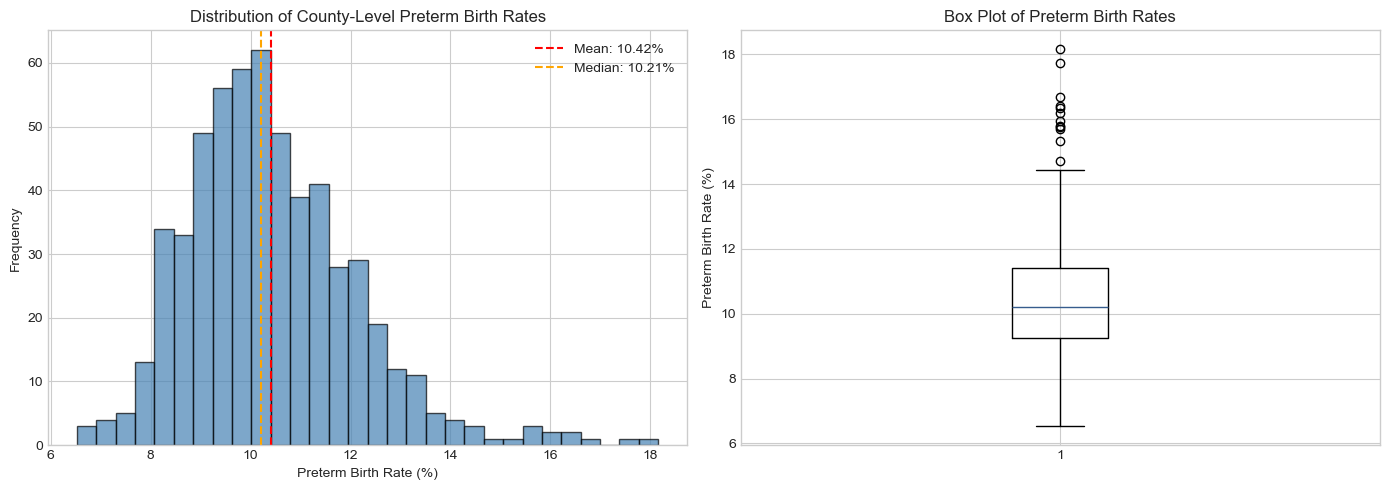

Figure 1: The distribution of preterm birth rates is slightly right-skewed, with most counties clustering around 9-11%.


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Preterm_Rate'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Preterm_Rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["Preterm_Rate"].mean():.2f}%')
axes[0].axvline(df['Preterm_Rate'].median(), color='orange', linestyle='--', label=f'Median: {df["Preterm_Rate"].median():.2f}%')
axes[0].set_xlabel('Preterm Birth Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of County-Level Preterm Birth Rates')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Preterm_Rate'], vert=True)
axes[1].set_ylabel('Preterm Birth Rate (%)')
axes[1].set_title('Box Plot of Preterm Birth Rates')

plt.tight_layout()
plt.savefig('fig1_preterm_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1: The distribution of preterm birth rates is slightly right-skewed, with most counties clustering around 9-11%.')

### 6.2 Distribution of Predictor Variables

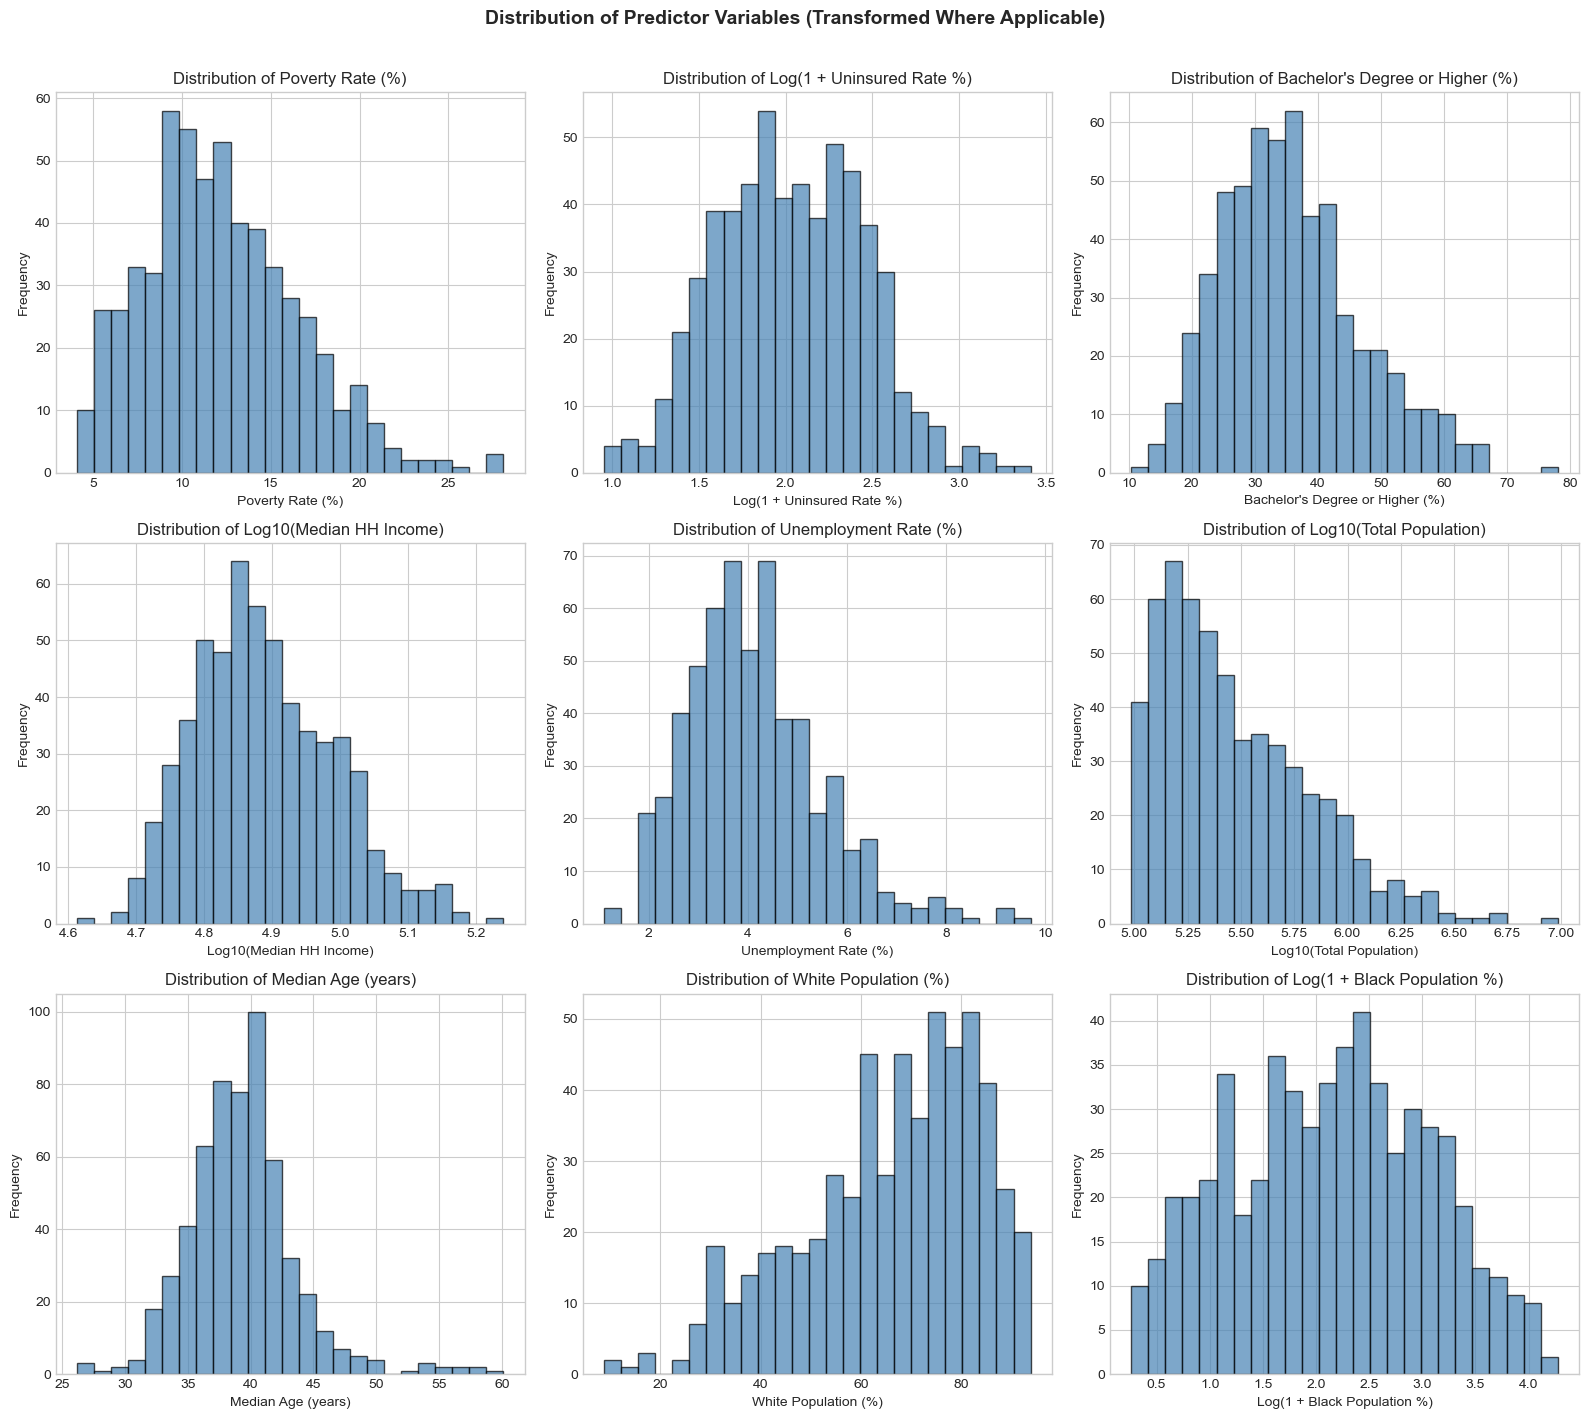

Figure 2: Distributions of predictor variables (with log-transformed versions) across 570 U.S. counties.


In [64]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

predictor_labels = {
    'Pct_Poverty': 'Poverty Rate (%)',
    'Log_Pct_Uninsured': 'Log(1 + Uninsured Rate %)',
    'Pct_Bachelors': "Bachelor's Degree or Higher (%)",
    'Log_Median_HH_Income': 'Log10(Median HH Income)',
    'Unemployment_Rate': 'Unemployment Rate (%)',
    'Log_Population': 'Log10(Total Population)',
    'Median_Age': 'Median Age (years)',
    'Pct_White': 'White Population (%)',
    'Log_Pct_Black': 'Log(1 + Black Population %)'
}

for idx, (col, label) in enumerate(predictor_labels.items()):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {label}')

plt.suptitle('Distribution of Predictor Variables (Transformed Where Applicable)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_predictor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2: Distributions of predictor variables (with log-transformed versions) across 570 U.S. counties.')

### 6.3 Correlation Analysis

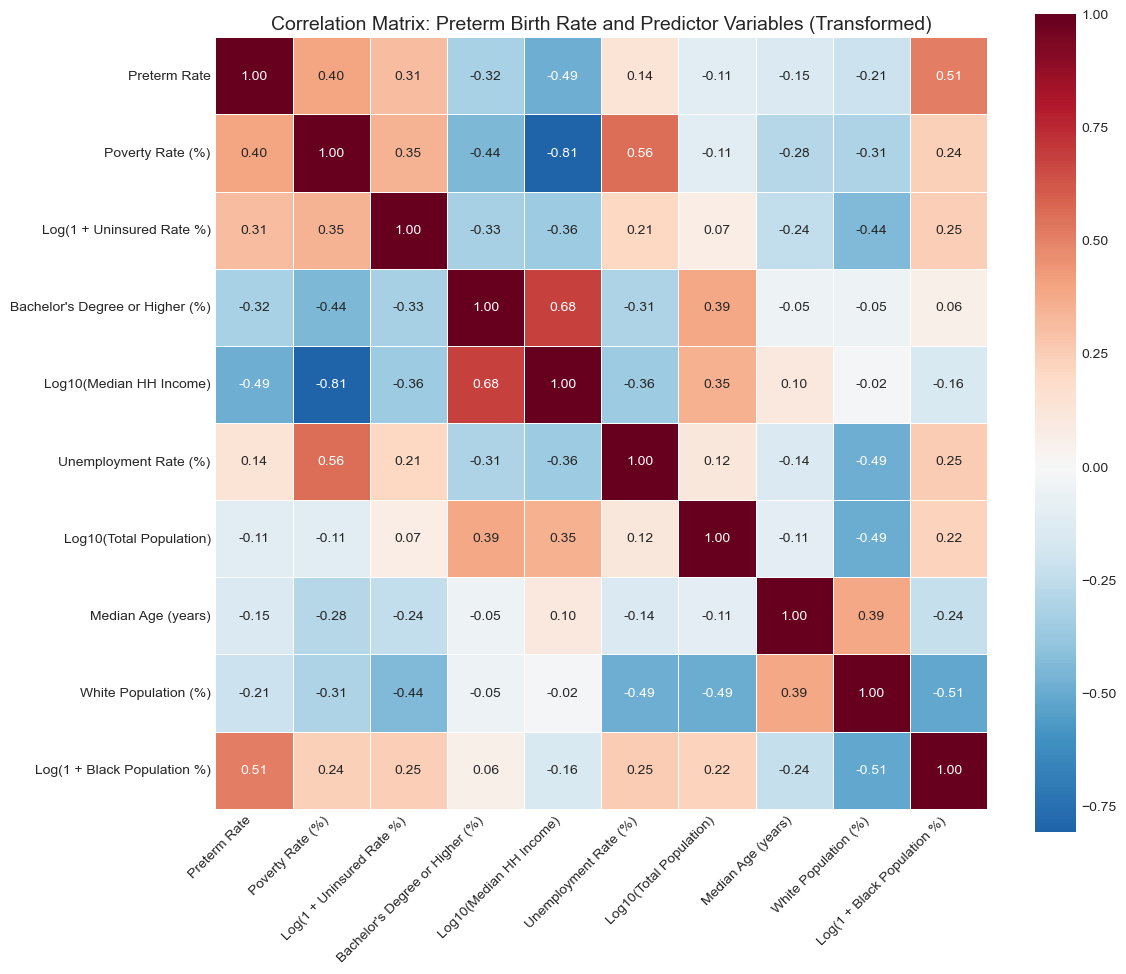

Correlation with Preterm Birth Rate (using transformed variables):
-------------------------------------------------------
Poverty Rate (%)                              r = +0.396
Log(1 + Uninsured Rate %)                     r = +0.308
Bachelor's Degree or Higher (%)               r = -0.323
Log10(Median HH Income)                       r = -0.490
Unemployment Rate (%)                         r = +0.136
Log10(Total Population)                       r = -0.112
Median Age (years)                            r = -0.155
White Population (%)                          r = -0.208
Log(1 + Black Population %)                   r = +0.508


In [67]:
# Correlation matrix using transformed variables
corr_cols = ['Preterm_Rate'] + list(predictor_labels.keys())
corr_matrix = df[corr_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=['Preterm Rate'] + list(predictor_labels.values()),
            yticklabels=['Preterm Rate'] + list(predictor_labels.values()))
ax.set_title('Correlation Matrix: Preterm Birth Rate and Predictor Variables (Transformed)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with outcome
print('Correlation with Preterm Birth Rate (using transformed variables):')
print('-' * 55)
for col in predictor_labels.keys():
    r = df['Preterm_Rate'].corr(df[col])
    print(f'{predictor_labels[col]:<45} r = {r:+.3f}')

### 6.4 Scatter Plots: Top Predictors vs. Preterm Birth Rate

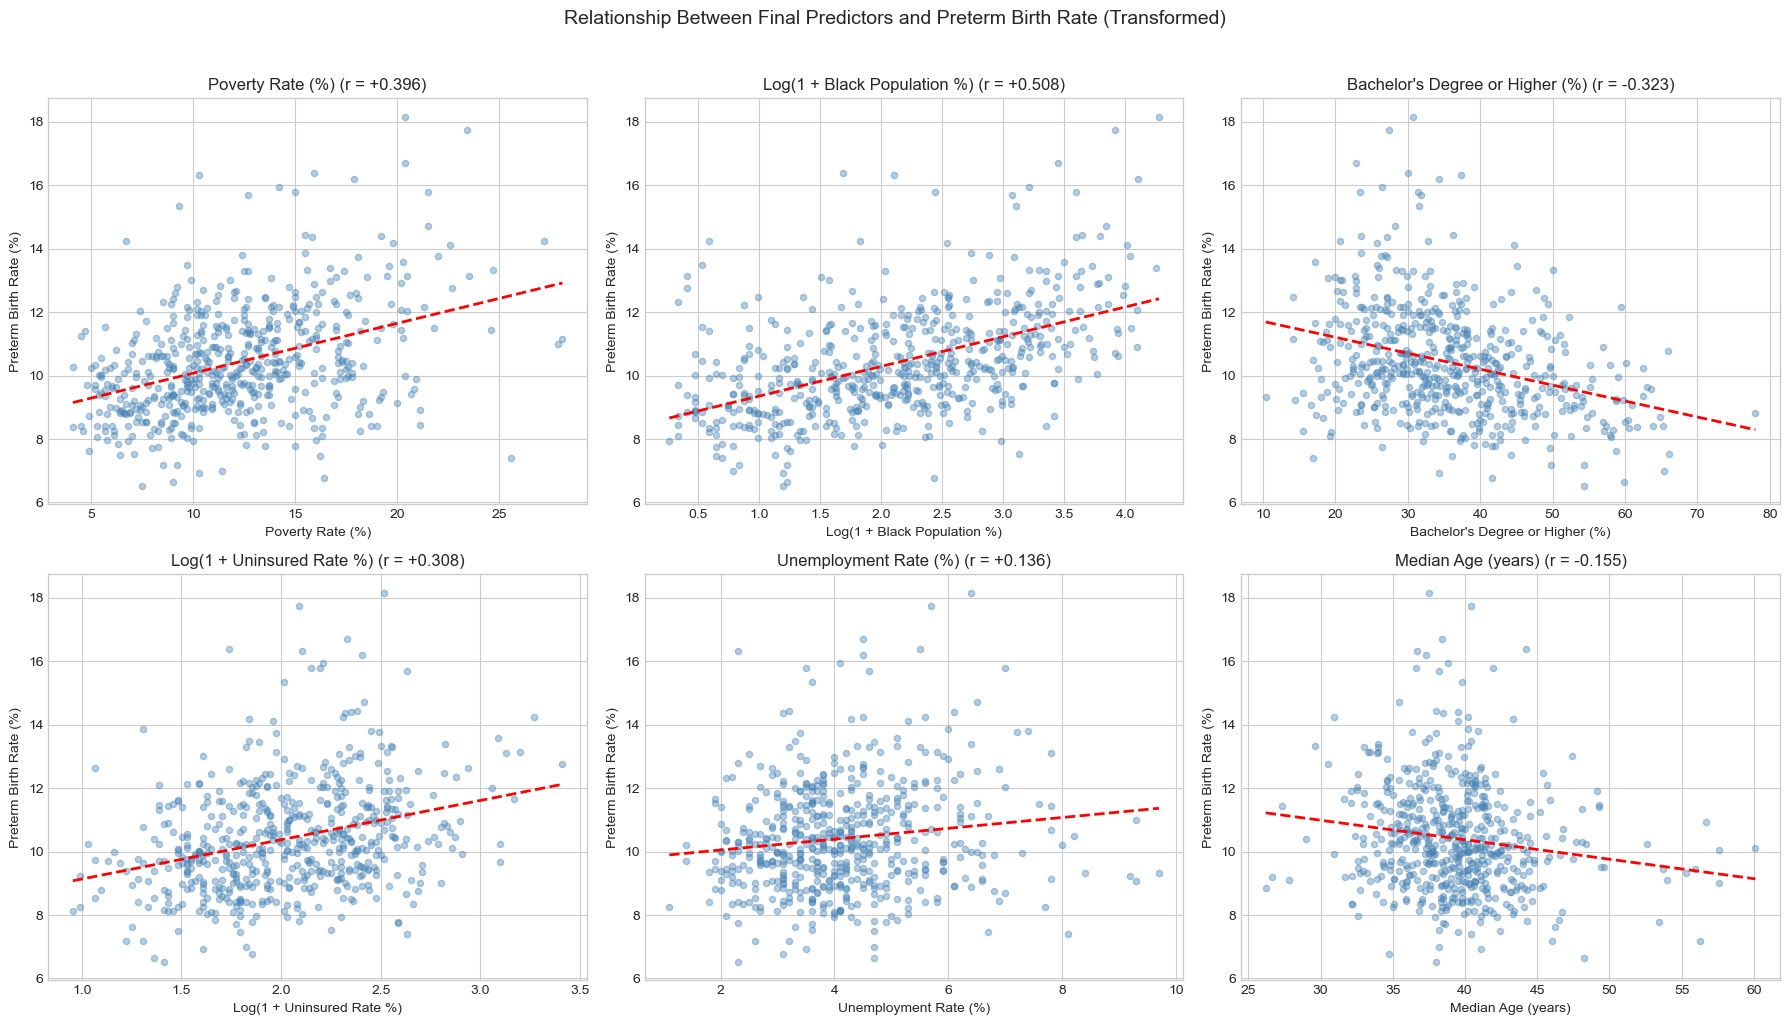

Figure 4: Scatter plots showing relationships between final predictor set and preterm birth rates.


In [70]:
# Scatter plots using the final GWR/OLS predictor set (transformed variables)
final_predictors = ['Pct_Poverty', 'Log_Pct_Black', 'Pct_Bachelors', 
                    'Log_Pct_Uninsured', 'Unemployment_Rate', 'Median_Age']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, col in enumerate(final_predictors):
    ax = axes[idx // 3, idx % 3]
    ax.scatter(df[col], df['Preterm_Rate'], alpha=0.4, s=20, color='steelblue')
    
    # Add trend line
    z = np.polyfit(df[col], df['Preterm_Rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)
    
    r = df['Preterm_Rate'].corr(df[col])
    ax.set_xlabel(predictor_labels.get(col, col))
    ax.set_ylabel('Preterm Birth Rate (%)')
    ax.set_title(f'{predictor_labels.get(col, col)} (r = {r:+.3f})')

plt.suptitle('Relationship Between Final Predictors and Preterm Birth Rate (Transformed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig4_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4: Scatter plots showing relationships between final predictor set and preterm birth rates.')

### 6.5 Spatial Distribution of Preterm Birth Rates

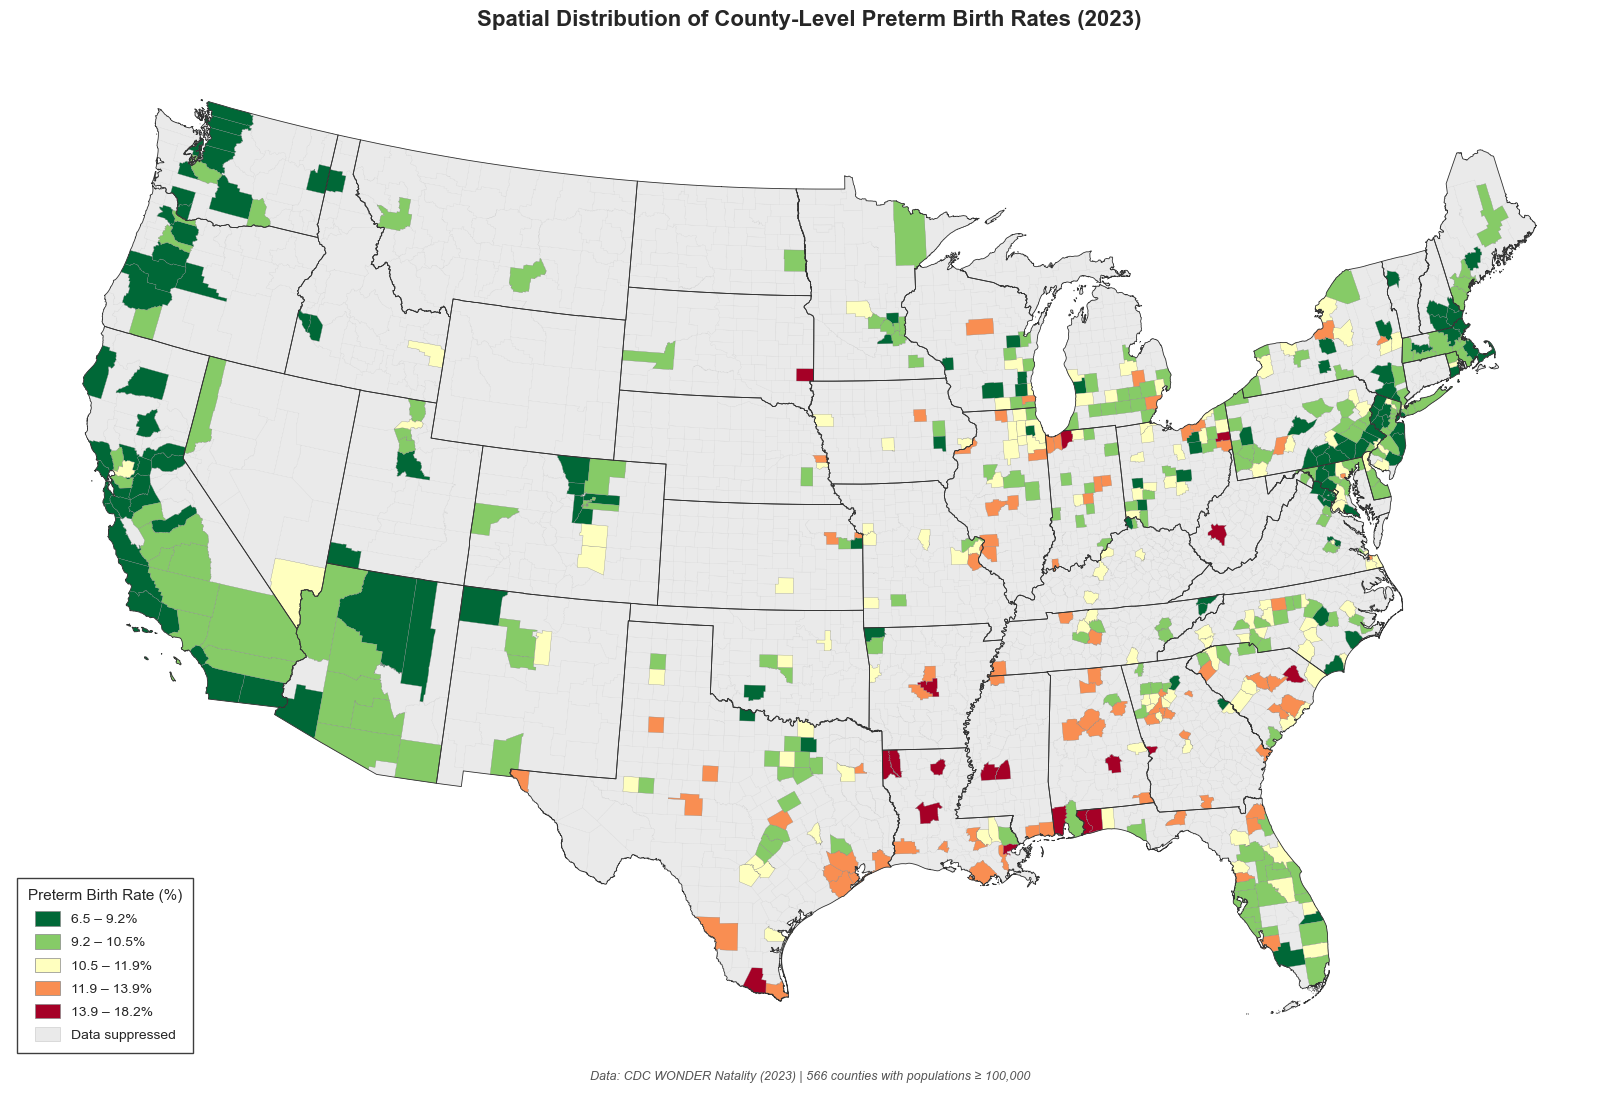

Figure 5: Choropleth map of county-level preterm birth rates across the contiguous U.S. (2023).
Classification: Natural Breaks (Jenks), k = 5 | Projection: Albers Equal Area Conic (EPSG:5070)
Gray polygons denote counties where CDC WONDER suppressed data due to small population size.


In [73]:
# ============================================================
# Figure 5: Choropleth — County-Level Preterm Birth Rates (2023)
# Publication-quality: Albers projection, state overlays, 
# rectangular legend, Natural Breaks (k=5)
# ============================================================
import matplotlib.patches as mpatches

# --- Reproject to Albers Equal Area Conic (EPSG:5070) ---
# Standard projection for thematic maps of the contiguous U.S.
gdf_proj = gdf.to_crs(epsg=5070)
counties_proj = counties_gdf.to_crs(epsg=5070)

# Derive state boundaries by dissolving county polygons
counties_proj_copy = counties_proj.copy()
if 'STATEFP' not in counties_proj_copy.columns:
    counties_proj_copy['STATEFP'] = counties_proj_copy['FIPS'].str[:2]
states_proj = counties_proj_copy.dissolve(by='STATEFP').reset_index()

# --- Natural Breaks classification (k=5) ---
classifier = mapclassify.NaturalBreaks(gdf_proj['Preterm_Rate'], k=5)
gdf_proj = gdf_proj.copy()
gdf_proj['class_bin'] = classifier.yb

# Color ramp: 5 discrete classes from RdYlGn_r
cmap = plt.colormaps.get_cmap('RdYlGn_r').resampled(5)
colors = [cmap(i) for i in range(5)]

# Formatted legend labels
bins = classifier.bins
lower_bounds = [gdf_proj['Preterm_Rate'].min()] + list(bins[:-1])
upper_bounds = list(bins)
legend_labels = [f'{lo:.1f} – {hi:.1f}%' for lo, hi in zip(lower_bounds, upper_bounds)]

# ---- FIGURE ----
fig, ax = plt.subplots(1, 1, figsize=(18, 11), facecolor='white')

# Layer 1: All continental counties as light gray background
counties_proj.plot(ax=ax, color='#EAEAEA', edgecolor='#D0D0D0', linewidth=0.15)

# Layer 2: Classified choropleth for study counties
for class_val in range(5):
    subset = gdf_proj[gdf_proj['class_bin'] == class_val]
    subset.plot(ax=ax, color=colors[class_val], edgecolor='#888888', linewidth=0.2)

# Layer 3: State boundaries for geographic reference
states_proj.boundary.plot(ax=ax, edgecolor='#333333', linewidth=0.6)

# ---- LEGEND (rectangular patches) ----
legend_patches = [
    mpatches.Patch(facecolor=colors[i], edgecolor='#888888',
                   linewidth=0.5, label=legend_labels[i])
    for i in range(5)
]
legend_patches.append(
    mpatches.Patch(facecolor='#EAEAEA', edgecolor='#D0D0D0',
                   linewidth=0.5, label='Data suppressed')
)

ax.legend(
    handles=legend_patches,
    loc='lower left',
    fontsize=10,
    title='Preterm Birth Rate (%)',
    title_fontsize=11,
    frameon=True,
    fancybox=False,
    edgecolor='#333333',
    framealpha=0.95,
    borderpad=0.8,
    labelspacing=0.6,
    handlelength=1.8,
    handleheight=1.2
)

# ---- CLEAN AXES (projected coords are meaningless to the reader) ----
ax.set_axis_off()

# ---- TITLE & SOURCE ----
ax.set_title(
    'Spatial Distribution of County-Level Preterm Birth Rates (2023)',
    fontsize=16, fontweight='bold', pad=20, fontfamily='sans-serif'
)
ax.annotate(
    f'Data: CDC WONDER Natality (2023) | {len(gdf_proj)} counties with populations ≥ 100,000',
    xy=(0.5, -0.02), xycoords='axes fraction', ha='center',
    fontsize=9, color='#555555', fontstyle='italic'
)

plt.tight_layout()
plt.savefig('fig5_spatial_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Figure 5: Choropleth map of county-level preterm birth rates across the contiguous U.S. (2023).')
print(f'Classification: Natural Breaks (Jenks), k = 5 | Projection: Albers Equal Area Conic (EPSG:5070)')
print(f'Gray polygons denote counties where CDC WONDER suppressed data due to small population size.')


## 7. Spatial Summary Statistics

In [72]:
# Spatial summary statistics using polygon centroids
gdf_centroids = gdf.copy()
gdf_centroids['centroid_lon'] = gdf_centroids.geometry.centroid.x
gdf_centroids['centroid_lat'] = gdf_centroids.geometry.centroid.y

# Mean center of all county centroids
mean_lon = gdf_centroids['centroid_lon'].mean()
mean_lat = gdf_centroids['centroid_lat'].mean()
print(f'Mean Center of All Counties: ({mean_lon:.4f}, {mean_lat:.4f})')

# Weighted mean center (weighted by preterm birth rate)
weighted_lon = np.average(gdf_centroids['centroid_lon'], weights=gdf_centroids['Preterm_Rate'])
weighted_lat = np.average(gdf_centroids['centroid_lat'], weights=gdf_centroids['Preterm_Rate'])
print(f'Weighted Mean Center (by Preterm Rate): ({weighted_lon:.4f}, {weighted_lat:.4f})')

# Standard distance
std_dist = np.sqrt(((gdf_centroids['centroid_lon'] - mean_lon)**2 + 
                     (gdf_centroids['centroid_lat'] - mean_lat)**2).mean())
print(f'Standard Distance: {std_dist:.4f} degrees')

# Interpretation
lon_shift = weighted_lon - mean_lon
lat_shift = weighted_lat - mean_lat
print(f'\nThe weighted mean center shifts {abs(lon_shift):.4f} degrees {"east" if lon_shift > 0 else "west"} '
      f'and {abs(lat_shift):.4f} degrees {"north" if lat_shift > 0 else "south"} compared to the unweighted center.')
print('This indicates that counties with higher preterm birth rates tend to be located further '
      f'{"east" if lon_shift > 0 else "west"} and {"south" if lat_shift < 0 else "north"} in the continental U.S.')

## 8. Summary of Preliminary Findings

This initial analysis reveals several important patterns in the data:

**Data Quality:** The dataset contains 570 U.S. counties with complete data across all 16 original variables (zero missing values, zero duplicates). County-level natality data from CDC WONDER are subject to privacy suppression for counties with populations below 100,000 persons, a standard constraint in county-level birth outcome research (Eiríksdóttir et al., 2014; Khan et al., 2023). The resulting analytic sample of 570 counties represents approximately 78% of the total U.S. birth population and exceeds the sample sizes used in comparable published studies (e.g., 524 counties in Eiríksdóttir et al., 2014).

**Variable Transformations:** Four variables (Total Population, Percentage Black, Percentage Uninsured, and Median Household Income) were log-transformed to address substantial positive skewness (original skewness values ranging from 1.1 to 6.8). All transformed variables achieved skewness below 1.0, approximating normal distributions suitable for regression analysis.

**Multicollinearity Resolution:** VIF analysis identified Median Household Income (VIF = 5.75) as the only variable exceeding the conventional threshold of 5. Based on both VIF scores and substantive considerations, Median Household Income and Percentage White were excluded from the regression predictor set, resulting in a final set of seven predictors with all VIF values below 5.

**Outcome Variable:** The county-level preterm birth rate ranges from 6.53% to 18.16% (mean = 10.42%), consistent with published national estimates. The distribution is slightly right-skewed, with upper outliers corresponding to counties in the southeastern United States.

**Key Predictor Relationships:** Correlation analysis reveals that preterm birth rates are positively associated with poverty rate and percentage of Black population, and negatively associated with educational attainment, median household income, and percentage of White population. Non-linear patterns in several scatter plots suggest that tree-based ML methods may outperform linear regression.

**Spatial Patterns:** The spatial visualization and weighted mean center analysis confirm geographic clustering of elevated preterm birth rates in the southeastern United States, motivating the use of GWR to explore spatially varying determinants.

### Next Steps

1. **Machine Learning Prediction:** Apply regression models (e.g., Random Forest, Gradient Boosting) using scikit-learn to predict county-level preterm birth rates and identify the most influential predictors through feature importance analysis.

2. **Geographically Weighted Regression (GWR):** Use the mgwr library to test whether the relationships between predictors and preterm birth rates exhibit spatial non-stationarity across U.S. counties.

3. **Spatial Autocorrelation:** Compute Moran's I to formally test for spatial clustering of preterm birth rates.

### References

Eiríksdóttir, V.H., et al. (2014). Exploration of Preterm Birth Rates Using the Public Health Exposome Database and Computational Analysis Methods. *International Journal of Environmental Research and Public Health*, 11(12), 12346–12366.

Khan, S.S., et al. (2023). US County-Level Variation in Preterm Birth Rates, 2007-2019. *JAMA Network Open*.